# Лабораторная работа: линейная регрессия на датасете Medical Cost Personal Datasets

**Цель работы:** изучение основ линейной регрессии, построение регрессионных моделей (линейная, Lasso, Ridge), обучение на реальных данных, оценка качества, устранение мультиколлинеарности методом главных компонент (PCA).

**Датасет:** [Medical Cost Personal Datasets](https://www.kaggle.com/datasets/mirichoi0218/insurance) (Kaggle, mirichoi0218) — 1338 записей о держателях медицинской страховки в США.

**Зависимая переменная (target):** `charges` — медицинские расходы, $

**Независимые переменные:** `age`, `sex`, `bmi`, `children`, `smoker`, `region`

## 1. Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

sns.set_theme(style="whitegrid", font_scale=1.0)
RANDOM_STATE = 42
print("Библиотеки импортированы")

Библиотеки импортированы


## 2. Загрузка и первичный анализ данных

Загружаем `insurance.csv`, смотрим на размер, типы столбцов, пропуски и описательные статистики.

In [2]:
df = pd.read_csv("insurance.csv")

print("Размер датасета:", df.shape)
print()
print("Типы данных:")
print(df.dtypes)
print()
print("Пропуски по столбцам:")
print(df.isna().sum())

Размер датасета: (1338, 7)

Типы данных:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Пропуски по столбцам:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


*Таблица 1. Первые строки датасета*

In [4]:
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


*Таблица 2. Описательные статистики по всем столбцам*

In [5]:
n_missing = int(df.isna().sum().sum())
n_dupes = int(df.duplicated().sum())
print("Всего пропущенных значений:", n_missing)
print("Число дублирующихся строк:", n_dupes)

Всего пропущенных значений: 0
Число дублирующихся строк: 1


**Вывод:** пропусков в данных нет. Обнаружена 1 полностью дублирующаяся строка — удалим её на этапе предобработки.

## 3. Визуализация распределений признаков и целевой переменной

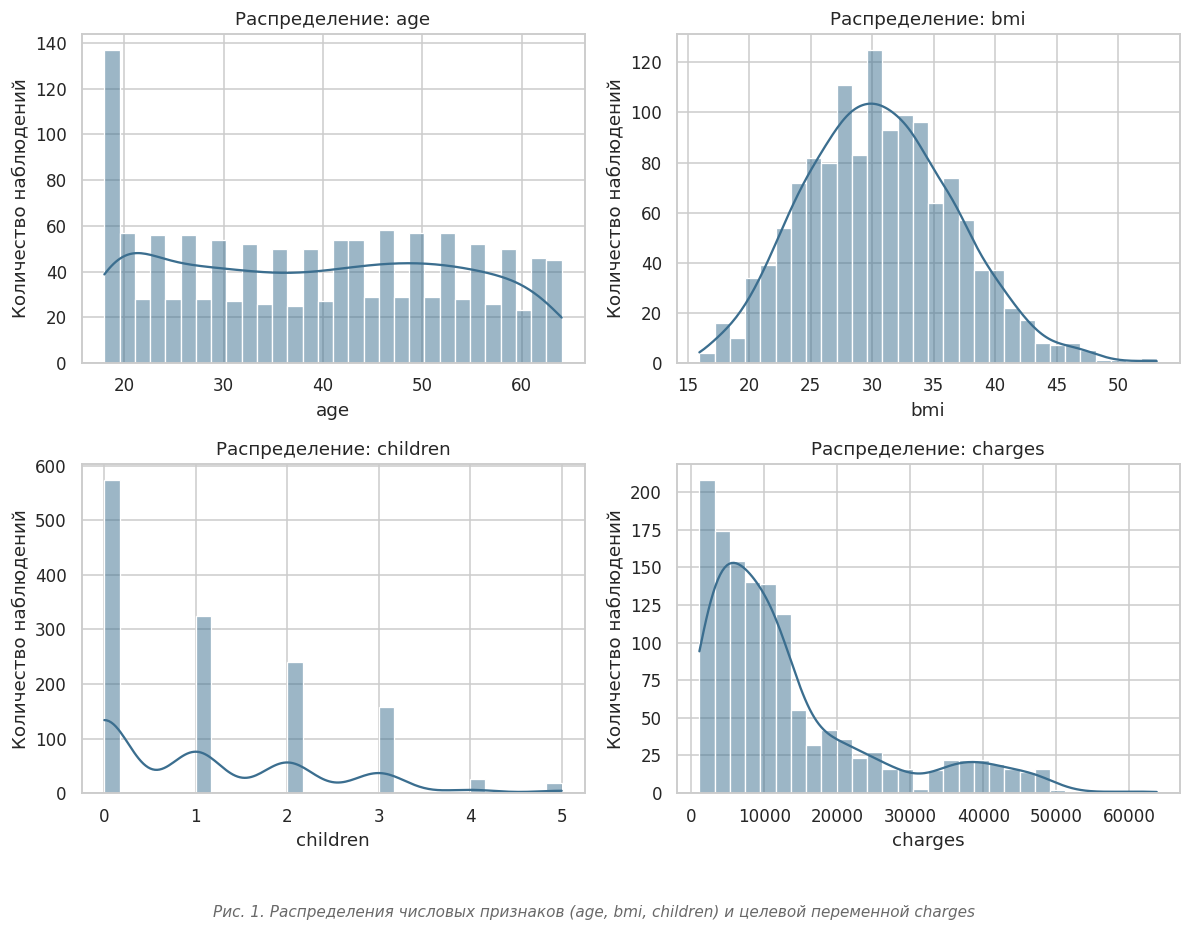

In [6]:
num_cols = ["age", "bmi", "children", "charges"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#3B6E8F", bins=30)
    ax.set_title(f"Распределение: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Количество наблюдений")
plt.tight_layout()
plt.figtext(0.5, -0.04, "Рис. 1. Распределения числовых признаков (age, bmi, children) и целевой переменной charges", ha="center", va="top", fontsize=10, style="italic", color="dimgray", wrap=True)

plt.show()

Возраст распределён почти равномерно (18–64 года), ИМТ близок к нормальному распределению (среднее ≈ 30.7), число детей — дискретное и скошено к 0. Целевая переменная `charges` сильно правоскошена: у большинства клиентов расходы небольшие, но есть "хвост" с очень высокими расходами (в основном курильщики).

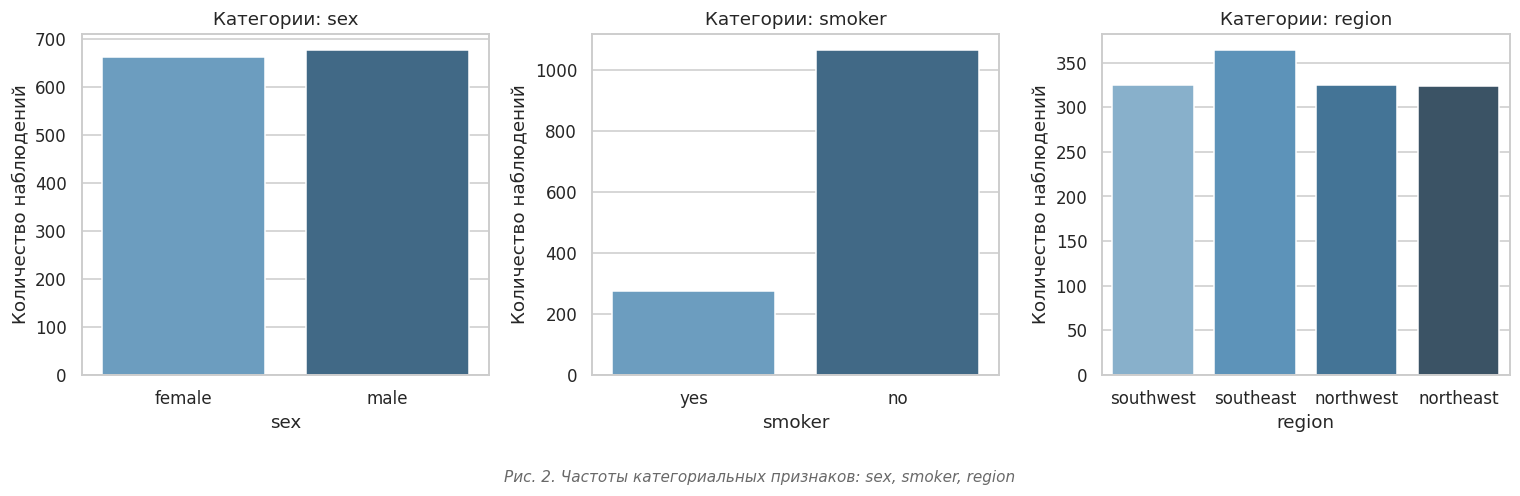

In [7]:
cat_cols = ["sex", "smoker", "region"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, data=df, ax=ax, palette="Blues_d")
    ax.set_title(f"Категории: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Количество наблюдений")
plt.tight_layout()
plt.figtext(0.5, -0.04, "Рис. 2. Частоты категориальных признаков: sex, smoker, region", ha="center", va="top", fontsize=10, style="italic", color="dimgray", wrap=True)

plt.show()

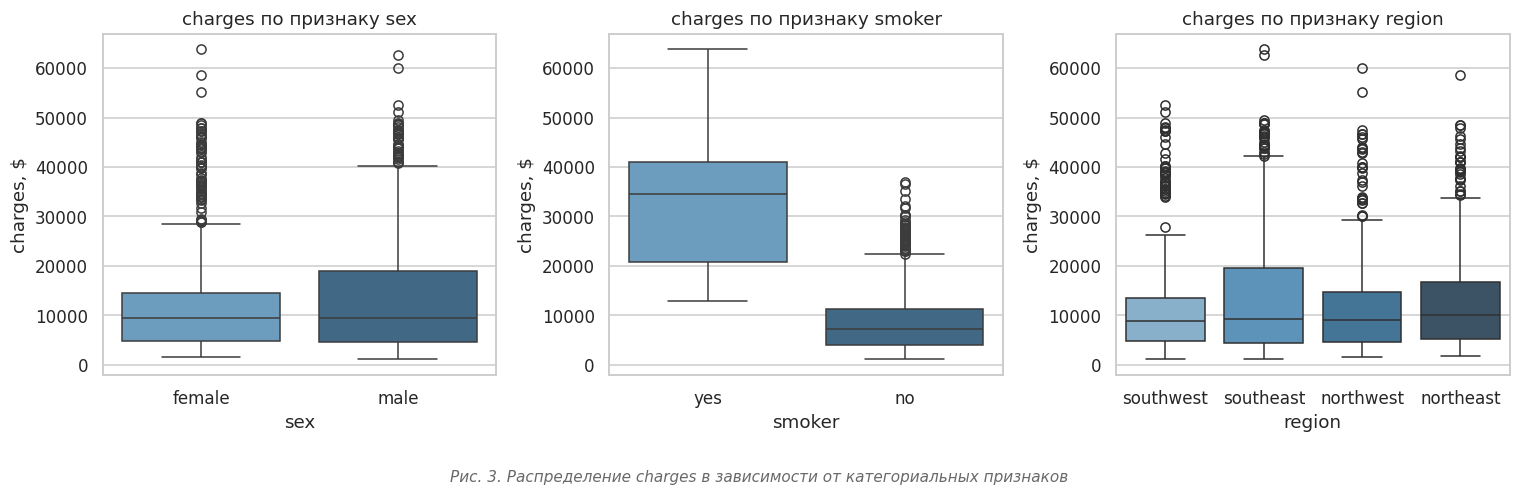

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, col in zip(axes, cat_cols):
    sns.boxplot(x=col, y="charges", data=df, ax=ax, palette="Blues_d")
    ax.set_title(f"charges по признаку {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("charges, $")
plt.tight_layout()
plt.figtext(0.5, -0.04, "Рис. 3. Распределение charges в зависимости от категориальных признаков", ha="center", va="top", fontsize=10, style="italic", color="dimgray", wrap=True)

plt.show()

Курение оказывает наиболее выраженное влияние на `charges`: медианные и максимальные расходы у курильщиков значительно выше. Влияние пола и региона визуально незначительно.

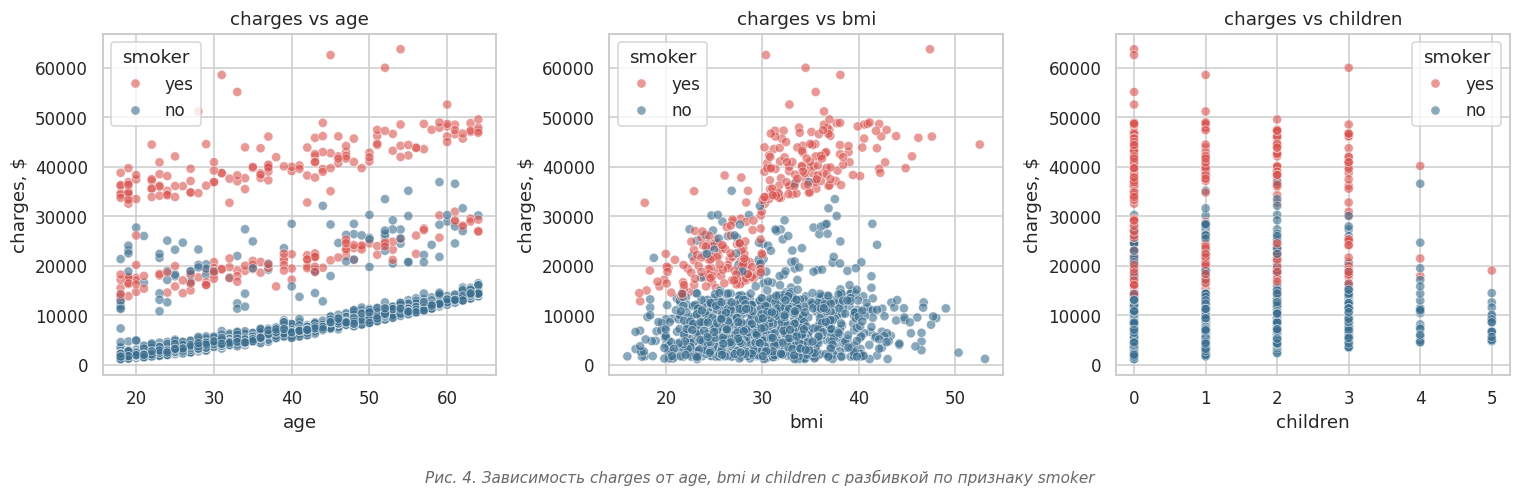

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
palette = {"yes": "#D9534F", "no": "#3B6E8F"}
for ax, col in zip(axes, ["age", "bmi", "children"]):
    sns.scatterplot(x=col, y="charges", hue="smoker", data=df, ax=ax, alpha=0.6, palette=palette)
    ax.set_title(f"charges vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("charges, $")
plt.tight_layout()
plt.figtext(0.5, -0.04, "Рис. 4. Зависимость charges от age, bmi и children с разбивкой по признаку smoker", ha="center", va="top", fontsize=10, style="italic", color="dimgray", wrap=True)

plt.show()

Среди курильщиков (красные точки) `charges` практически линейно растёт с возрастом и ИМТ; среди некурящих (синие точки) расходы растут значительно медленнее.

## 4. Предобработка данных

- удаляем дубликаты и пропуски;
- кодируем `sex` и `smoker` бинарно;
- кодируем `region` методом one-hot (drop_first, чтобы избежать дамми-ловушки);
- формируем матрицу признаков X и вектор целевой переменной y.

In [10]:
df_clean = df.drop_duplicates().dropna().reset_index(drop=True)
print("Размер после очистки:", df_clean.shape)

df_enc = df_clean.copy()
df_enc["sex"] = df_enc["sex"].map({"male": 1, "female": 0})
df_enc["smoker"] = df_enc["smoker"].map({"yes": 1, "no": 0})
df_enc = pd.get_dummies(df_enc, columns=["region"], drop_first=True)
bool_cols = df_enc.select_dtypes(include="bool").columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

df_enc.head()

Размер после очистки: (1337, 7)


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


*Таблица 3. Данные после кодирования категориальных признаков (первые строки)*

In [11]:
feature_cols = [c for c in df_enc.columns if c != "charges"]
X = df_enc[feature_cols].astype(float)
y = df_enc["charges"].astype(float)

print("Признаки:", feature_cols)
print("X:", X.shape, " y:", y.shape)

Признаки: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
X: (1337, 8)  y: (1337,)


## 5. Корреляционная матрица и VIF (мультиколлинеарность)

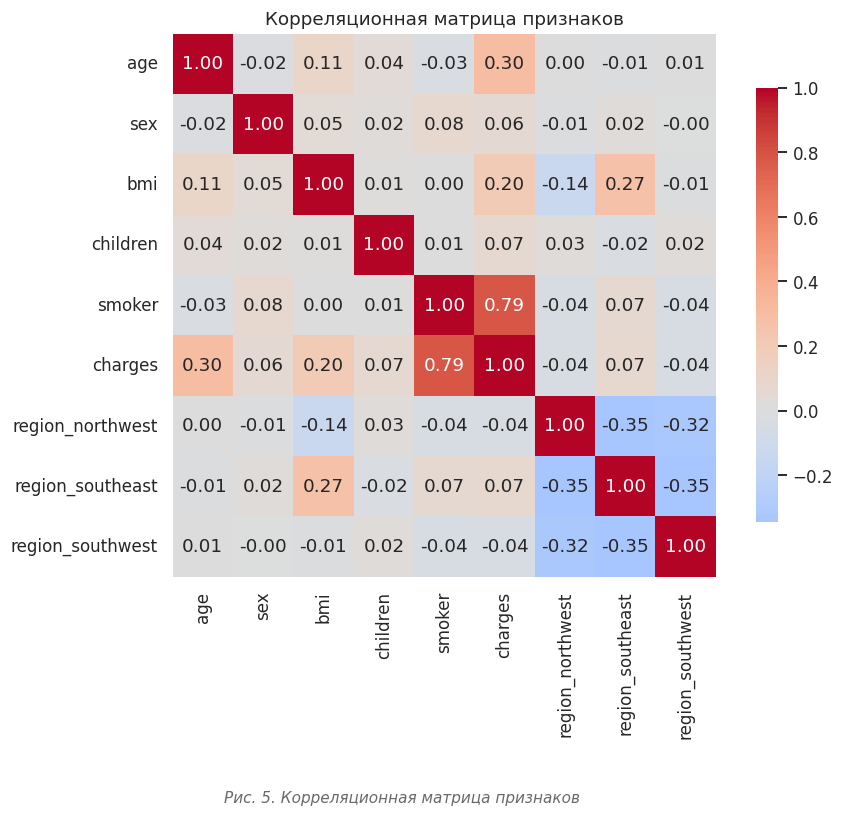

In [12]:
corr = df_enc.corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .8})
plt.title("Корреляционная матрица признаков")
plt.tight_layout()
plt.figtext(0.5, -0.04, "Рис. 5. Корреляционная матрица признаков", ha="center", va="top", fontsize=10, style="italic", color="dimgray", wrap=True)

plt.show()

Наиболее сильная связь с целевой переменной — у признака `smoker` (r ≈ 0.79). `age` коррелирует с `charges` на уровне r ≈ 0.30, `bmi` — r ≈ 0.20. Связи между независимыми признаками слабые (|r| < 0.35), что говорит об отсутствии сильной мультиколлинеарности.

In [13]:
def compute_vif(X_df):
    """VIF_i = 1 / (1 - R^2_i), где R^2_i — из регрессии признака i на все остальные признаки."""
    vifs = []
    cols = X_df.columns
    for col in cols:
        y_i = X_df[col].values
        X_other = X_df.drop(columns=[col]).values
        lr = LinearRegression().fit(X_other, y_i)
        r2 = r2_score(y_i, lr.predict(X_other))
        vif = np.inf if r2 >= 1.0 else 1.0 / (1.0 - r2)
        vifs.append(vif)
    return pd.DataFrame({"feature": cols, "VIF": vifs}).sort_values("VIF", ascending=False)

vif_df = compute_vif(X)
vif_df

,feature,VIF
6,region_southeast,1.651779
7,region_southwest,1.529044
5,region_northwest,1.517673
2,bmi,1.106742
0,age,1.016794
4,smoker,1.012100
1,sex,1.008944
3,children,1.004017


*Таблица 4. VIF-коэффициенты признаков (исходные данные)*

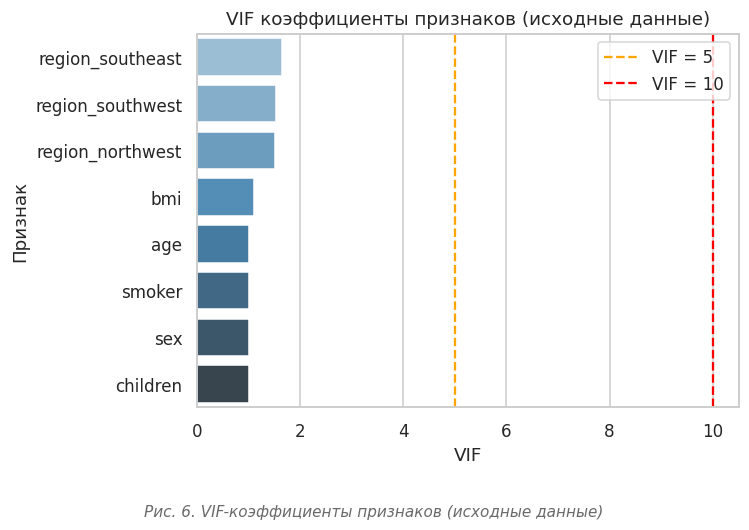

In [14]:
plt.figure(figsize=(7, 4.5))
sns.barplot(x="VIF", y="feature", data=vif_df, palette="Blues_d")
plt.axvline(5, color="orange", ls="--", label="VIF = 5")
plt.axvline(10, color="red", ls="--", label="VIF = 10")
plt.legend()
plt.xlabel("VIF")
plt.ylabel("Признак")
plt.title("VIF коэффициенты признаков (исходные данные)")
plt.tight_layout()
plt.figtext(0.5, -0.04, "Рис. 6. VIF-коэффициенты признаков (исходные данные)", ha="center", va="top", fontsize=10, style="italic", color="dimgray", wrap=True)

plt.show()

**Вывод:** все значения VIF значительно меньше порога 5 (максимум ≈ 1.65 у `region_southeast`). Мультиколлинеарность в исходном наборе признаков отсутствует.

## 6. Регрессионные модели на исходных признаках

Разбиваем выборку на train/test (80/20), обучаем линейную, Lasso- и Ridge-регрессию, оцениваем с помощью RMSE, R² и MAPE, применяем 5-блочную кросс-валидацию.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    mape = mean_absolute_percentage_error(y_te, y_pred) * 100
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=kf, scoring="r2")
    return {
        "model": name, "RMSE": rmse, "R2": r2, "MAPE_%": mape,
        "CV_R2_mean": cv_r2.mean(), "CV_R2_std": cv_r2.std()
    }, y_pred

print(f"Train: {X_train.shape[0]} наблюдений, Test: {X_test.shape[0]} наблюдений")

Train: 1069 наблюдений, Test: 268 наблюдений


In [16]:
results_orig = []
preds_orig = {}

lr = LinearRegression()
res, pred = evaluate_model(lr, X_train, y_train, X_test, y_test, "Linear Regression")
results_orig.append(res); preds_orig["Linear"] = pred

lasso = Lasso(alpha=50, max_iter=20000, random_state=RANDOM_STATE)
res, pred = evaluate_model(lasso, X_train, y_train, X_test, y_test, "Lasso (alpha=50)")
results_orig.append(res); preds_orig["Lasso"] = pred

ridge = Ridge(alpha=10, random_state=RANDOM_STATE)
res, pred = evaluate_model(ridge, X_train, y_train, X_test, y_test, "Ridge (alpha=10)")
results_orig.append(res); preds_orig["Ridge"] = pred

results_orig_df = pd.DataFrame(results_orig)
results_orig_df

,model,RMSE,R2,MAPE_%,CV_R2_mean,CV_R2_std
0,Linear Regression,5956.342894,0.806929,41.396756,0.722784,0.028260
1,Lasso (alpha=50),6018.560711,0.802874,42.334938,0.723320,0.027013
2,Ridge (alpha=10),6118.852366,0.796250,43.852973,0.720264,0.024399


*Таблица 5. Метрики качества моделей на исходных признаках*

In [17]:
coef_df = pd.DataFrame({"feature": feature_cols, "coef": lr.coef_}).sort_values("coef", key=abs, ascending=False)
coef_df

,feature,coef
4,smoker,23077.764593
6,region_southeast,-838.919616
7,region_southwest,-659.139752
3,children,533.009989
5,region_northwest,-391.761455
2,bmi,318.701441
0,age,248.210720
1,sex,-101.542054


*Таблица 6. Коэффициенты линейной регрессии на исходных признаках*

**Вывод:** наилучший результат на исходных признаках показала обычная линейная регрессия без регуляризации (R² ≈ 0.807). Регуляризация здесь не даёт выигрыша, т.к. мультиколлинеарность отсутствует. Наибольший вклад в прогноз вносит `smoker` (+23078 $ к расходам).

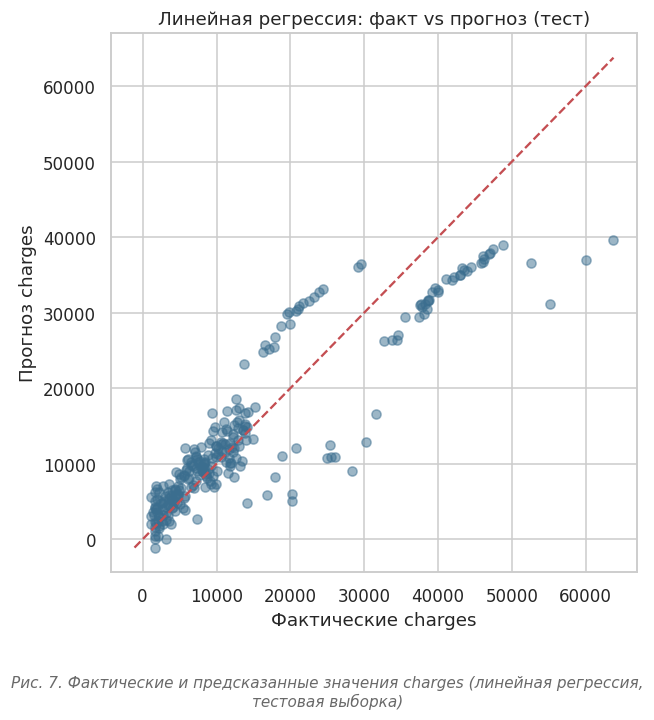

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds_orig["Linear"], alpha=0.5, color="#3B6E8F")
lims = [min(y_test.min(), preds_orig["Linear"].min()), max(y_test.max(), preds_orig["Linear"].max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Фактические charges")
plt.ylabel("Прогноз charges")
plt.title("Линейная регрессия: факт vs прогноз (тест)")
plt.tight_layout()
plt.figtext(0.5, -0.04, "Рис. 7. Фактические и предсказанные значения charges (линейная регрессия, тестовая выборка)", ha="center", va="top", fontsize=10, style="italic", color="dimgray", wrap=True)

plt.show()

## 7. Стандартизация и метод главных компонент (PCA)

Стандартизируем признаки (StandardScaler, обучается только на train) и строим scree plot — график доли объяснённой дисперсии по компонентам.

Доля объяснённой дисперсии: [0.1904 0.1671 0.1416 0.1317 0.1225 0.1125 0.096  0.0382]
Накопленная доля: [0.1904 0.3575 0.4991 0.6309 0.7533 0.8659 0.9618 1.    ]


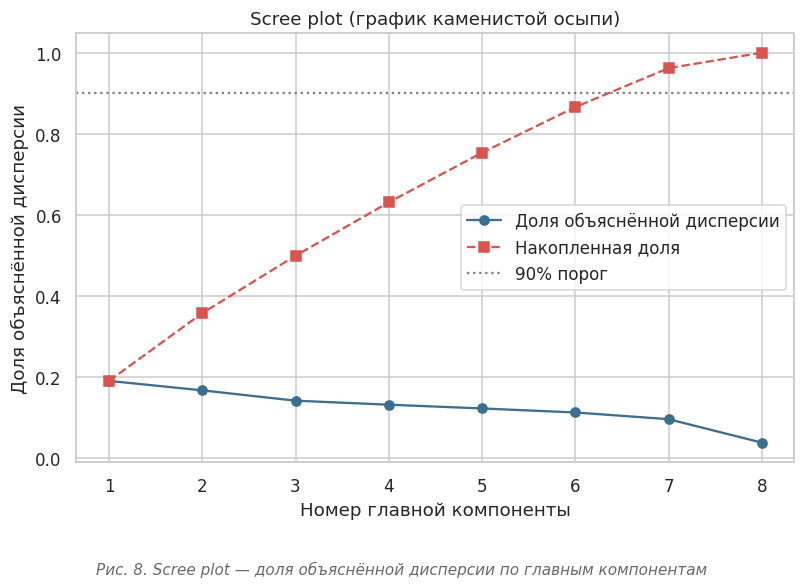

In [19]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_sc)
explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(7.5, 5))
plt.plot(range(1, len(explained) + 1), explained, "o-", color="#3B6E8F", label="Доля объяснённой дисперсии")
plt.plot(range(1, len(explained) + 1), cum_explained, "s--", color="#D9534F", label="Накопленная доля")
plt.axhline(0.9, color="gray", ls=":", label="90% порог")
plt.xlabel("Номер главной компоненты")
plt.ylabel("Доля объяснённой дисперсии")
plt.title("Scree plot (график каменистой осыпи)")
plt.legend()
plt.tight_layout()
plt.figtext(0.5, -0.04, "Рис. 8. Scree plot — доля объяснённой дисперсии по главным компонентам", ha="center", va="top", fontsize=10, style="italic", color="dimgray", wrap=True)

plt.show()

print("Доля объяснённой дисперсии:", np.round(explained, 4))
print("Накопленная доля:", np.round(cum_explained, 4))

In [20]:
n_components = int(np.argmax(cum_explained >= 0.90) + 1)
print(f"Число компонент для 90% дисперсии: {n_components} из {X.shape[1]}")

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca = pca.transform(X_test_sc)

pc_cols = [f"PC{i+1}" for i in range(n_components)]
vif_pca = compute_vif(pd.DataFrame(X_train_pca, columns=pc_cols))
vif_pca

Число компонент для 90% дисперсии: 7 из 8


,feature,VIF
4,PC5,1.0
6,PC7,1.0
0,PC1,1.0
2,PC3,1.0
1,PC2,1.0
5,PC6,1.0
3,PC4,1.0


*Таблица 7. VIF главных компонент (ожидаемо равны 1.0 — компоненты ортогональны)*

**Вывод:** дисперсия распределена почти равномерно между всеми компонентами — ни одна не доминирует (следствие изначально низкой корреляции признаков). Для 90% дисперсии требуется 7 из 8 компонент — существенного снижения размерности не достигнуто. VIF компонент равен 1.0 — они полностью ортогональны по построению.

## 8. Регрессионные модели на главных компонентах

In [21]:
results_pca = []

lr_p = LinearRegression()
res, _ = evaluate_model(lr_p, X_train_pca, y_train, X_test_pca, y_test, "Linear Regression (PCA)")
results_pca.append(res)

lasso_p = Lasso(alpha=50, max_iter=20000, random_state=RANDOM_STATE)
res, _ = evaluate_model(lasso_p, X_train_pca, y_train, X_test_pca, y_test, "Lasso (PCA)")
results_pca.append(res)

ridge_p = Ridge(alpha=10, random_state=RANDOM_STATE)
res, _ = evaluate_model(ridge_p, X_train_pca, y_train, X_test_pca, y_test, "Ridge (PCA)")
results_pca.append(res)

results_pca_df = pd.DataFrame(results_pca)
results_pca_df

,model,RMSE,R2,MAPE_%,CV_R2_mean,CV_R2_std
0,Linear Regression (PCA),5990.088381,0.804735,41.385086,0.721945,0.028956
1,Lasso (PCA),6023.550362,0.802547,41.567993,0.721894,0.028239
2,Ridge (PCA),6018.585242,0.802873,41.876019,0.721956,0.028068


*Таблица 8. Метрики качества моделей на главных компонентах (PCA)*

## 9. Сравнение метрик: исходные признаки vs PCA

In [22]:
comparison = pd.DataFrame({
    "Model": ["Linear", "Lasso", "Ridge"],
    "RMSE_orig": results_orig_df["RMSE"].values,
    "RMSE_pca": results_pca_df["RMSE"].values,
    "R2_orig": results_orig_df["R2"].values,
    "R2_pca": results_pca_df["R2"].values,
    "MAPE_orig_%": results_orig_df["MAPE_%"].values,
    "MAPE_pca_%": results_pca_df["MAPE_%"].values,
})
comparison

,Model,RMSE_orig,RMSE_pca,R2_orig,R2_pca,MAPE_orig_%,MAPE_pca_%
0,Linear,5956.342894,5990.088381,0.806929,0.804735,41.396756,41.385086
1,Lasso,6018.560711,6023.550362,0.802874,0.802547,42.334938,41.567993
2,Ridge,6118.852366,6018.585242,0.796250,0.802873,43.852973,41.876019


*Таблица 9. Сравнение метрик: исходные признаки vs главные компоненты (PCA)*

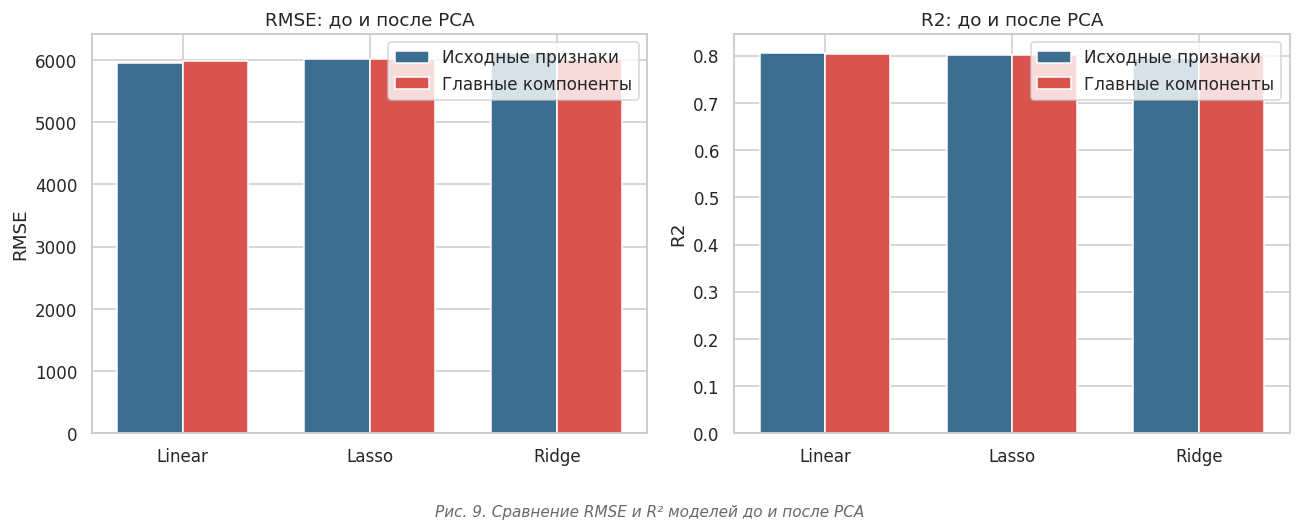

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(comparison))
w = 0.35

axes[0].bar(x - w/2, comparison["RMSE_orig"], w, label="Исходные признаки", color="#3B6E8F")
axes[0].bar(x + w/2, comparison["RMSE_pca"], w, label="Главные компоненты", color="#D9534F")
axes[0].set_xticks(x); axes[0].set_xticklabels(comparison["Model"])
axes[0].set_ylabel("RMSE"); axes[0].set_title("RMSE: до и после PCA"); axes[0].legend()

axes[1].bar(x - w/2, comparison["R2_orig"], w, label="Исходные признаки", color="#3B6E8F")
axes[1].bar(x + w/2, comparison["R2_pca"], w, label="Главные компоненты", color="#D9534F")
axes[1].set_xticks(x); axes[1].set_xticklabels(comparison["Model"])
axes[1].set_ylabel("R2"); axes[1].set_title("R2: до и после PCA"); axes[1].legend()

plt.tight_layout()
plt.figtext(0.5, -0.04, "Рис. 9. Сравнение RMSE и R² моделей до и после PCA", ha="center", va="top", fontsize=10, style="italic", color="dimgray", wrap=True)

plt.show()

**Вывод:** качество моделей на главных компонентах практически не отличается от качества на исходных признаках (разница RMSE < 100$, разница R² < 0.007). Для Ridge-регрессии PCA дал небольшое улучшение (R² вырос с 0.796 до 0.803). Это ожидаемо: PCA даёт наибольший эффект при высокой мультиколлинеарности исходных признаков, которая в этом датасете отсутствует.

## 10. Заключение

- Датасет не содержит пропусков; обнаружен и удалён 1 дубликат строки.
- Анализ VIF показал отсутствие значимой мультиколлинеарности (все VIF < 2).
- Лучшая модель на исходных признаках — линейная регрессия без регуляризации: **RMSE ≈ 5956, R² ≈ 0.807, MAPE ≈ 41.4%**. Главный фактор расходов — признак `smoker`.
- PCA не позволил существенно снизить размерность (7 из 8 компонент для 90% дисперсии) и не улучшил качество линейной и Lasso-регрессии; для Ridge — минимальное улучшение.
- Результат согласуется с теорией: PCA эффективен при высокой мультиколлинеарности, которой в этом датасете нет.
- Для дальнейшего повышения точности имеет смысл рассмотреть нелинейные модели (полиномиальные признаки, градиентный бустинг), поскольку зависимость `charges` от `age`/`bmi` у курильщиков носит выраженный нелинейный (ступенчатый) характер.

## Список источников

1. Medical Cost Personal Datasets. Kaggle. https://www.kaggle.com/datasets/mirichoi0218/insurance
2. Pedregosa F. et al. Scikit-learn: Machine Learning in Python // JMLR, 2011.
3. James G., Witten D., Hastie T., Tibshirani R. An Introduction to Statistical Learning. Springer, 2021.
4. Документация scikit-learn, pandas, matplotlib, seaborn.